<a href="https://colab.research.google.com/github/SvetaTrusova/LR2_Data_visualisation/blob/main/labs/%D0%9B%D0%A03_%D0%9E%D0%B1%D0%B5%D1%81%D0%BF%D0%B5%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные



В папке [Data/lab3](https://drive.google.com/drive/folders/1437z7m5Ut4WUJOhJg1oZz13dtBpxgFKs?usp=share_link) расположена таблица `monster_com_job_sample.com` с данными о вакансиях. Также эти данные с описанием и примерами обработки можно найти на [kaggle](https://www.kaggle.com/code/ankkur13/perfect-dataset-to-get-the-hands-dirty/data#).

##### **Формат данных**

```
country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
United States of America,US,"",No,jobs.monster.com,"TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and judgment to plan and accomplish goals. Required Skills:вАҐ Call tracking softwareвАҐ Phone based technical supportвАҐ Problem documentation and communicationвАҐ Remote Desktop Management ToolsвАҐ Respond to customer requestsвАҐ General understanding of LANDeskвАҐ Microsoft Office 2007 SuiteFind out why TeamSoft is the Madison area's technology leader with over 200 IT consultants. Owned, operated, and managed by IT consultants, TeamSoft is the clear choice for your career. Join the TeamSoft family today!Did you know?вАҐ TeamSoft offers salaried options for many positions that include 5 weeks PTO and great benefits!вАҐ TeamSoft has been in business since 1996вАҐ TeamSoft's owners are local IT professionals who possess a wealth of experience in application development, business analysis, and project managementвАҐ TeamSoft's Recruiters are knowledgeable, friendly, and ready to help you make your next great career moveвАҐ TeamSoft offers a full benefits suite to all of our W2 consultants, including a 401k plan with a 100% vested 4% dollar for dollar matchвАҐ Our targeted selection process is designed to get to know your strengths and career interests and provide you with the best chance for success in your new positionвАҐ Our longest running consultant has been with us for 16 yearsвАҐ Consultants can participate in our charitable giving committee. To date, TeamSoft's charitable giving committee has donated over $100,000!TeamSoft is owned by local IT professionals. Our team also has deep experience with IT staffing. Our clients understand this and rely on our expertise. That is why TeamSoft is the Madison Area's largest privately owned IT consulting firm, with more than 200 current consultants! With over 50 active clients, TeamSoft will give you the greatest exposure to the widest range of IT careers.Our owners possess a combined 60+ years of IT consulting experience. Our recruiting and Account Management staff are very well-versed in our client markets. We get you. We know you. We know what you do every day. And we know what you deal with on the job.You take your career seriously and so do we. At TeamSoft you are not just a resume or number. Our goal is to create long-term partnerships with each of our consultants, and according to feedback from many of them, we are very good at this. Click HERE to see what our consultants have to say about working with TeamSoft.TeamSoft -- Promote yourself!TeamSoft is an equal employment opportunity employer functioning under an Affirmative Action Plan.",IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702","",http://jobview.monster.com/it-support-technician-job-madison-wi-us-167855963.aspx?mescoid=1500134001001&jobPosition=20,"",IT/Software Development,11d599f229a80023d2f40e7c52cd941e
United States of America,US,"",No,jobs.monster.com,"The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. WeвАЩre looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison areaвАЩs vibrant entrepreneurial community. This is a hybrid reporting and editing position that calls for a fleet-footed, multimedia storyteller able to maximize the newspaperвАЩs online presentation while also editing two sections a week. Candidates must have strong news judgment, be well versed in business news and trends and be able to quickly prioritize coverage.At least five yearsвАЩ experience reporting or editing for digital and print platforms desired. To be considered for the position, applicants must apply online.¬†As part of your online application, please attach five samples of your work or links to five recent stories.Wisconsin State Journal, 1901 Fish Hatchery Road, Madison, WI 53713Affirmative Action/Equal Opportunity Employer/Pre-employment drug testing appliesPI94338362Apply Here",Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-editor-job-madison-wi-us-167830105.aspx?mescoid=2700437001001&jobPosition=7,"","",e4cbb126dabf22159aff90223243ff2a
...
```

##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [1]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded['monster_com_job_sample.csv']))
print(f"✅ Данные загружены. Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")


Saving monster_com_job_sample.csv to monster_com_job_sample.csv
✅ Данные загружены. Размер: 22000 строк, 14 столбцов


В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

In [3]:
print("СЛУЧАЙНЫЕ 200 СТРОК:")
print(df.sample(200))

print("\nИНФОРМАЦИЯ О СТОБЦАХ:")
print(df.info())

СЛУЧАЙНЫЕ 200 СТРОК:
                        country country_code date_added has_expired  \
20620  United States of America           US        NaN          No   
18124  United States of America           US        NaN          No   
15113  United States of America           US        NaN          No   
54     United States of America           US        NaN          No   
14373  United States of America           US        NaN          No   
...                         ...          ...        ...         ...   
19761  United States of America           US        NaN          No   
12488  United States of America           US        NaN          No   
16910  United States of America           US        NaN          No   
17190  United States of America           US        NaN          No   
13215  United States of America           US        NaN          No   

              job_board                                    job_description  \
20620  jobs.monster.com  CNA - Per Diem - Harbor

**Задание**

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.


| Название столбца | Тип данных | Проблемы |
|-----------------|------------|----------|
| country | object | Все значения одинаковые ("United States of America") - можно удалить |
| country_code | object | Все значения одинаковые ("US") - можно удалить |
| date_added | object | Почти все значения NaN, нестандартный формат даты|
| has_expired | object | Все значения "No" - избыточный столбец |
| job_board | object | Все значения "jobs.monster.com" - константа |
| job_description | object | Длинный текст, есть HTML-теги, спецсимволы |
| job_title | object | Содержит город в названии (Job in City), дублирует location |
| job_type | object | Разные форматы: "Full Time Employee", "Full Time, Employee", "Full Time" и т.д. |
| location | object | Разные форматы: "Город, ШТ", "Город, ШТ Индекс", только "Город" |
| organization | object | Много NaN, иногда содержит несколько значений через пробел |
| page_url | object | Уникальные URL для каждой вакансии |
| salary | object | Разные форматы: диапазоны, "Up to...", единичные значения, много NaN |
| sector | object | Много NaN, иногда содержит организацию |
| uniq_id | object | Уникальные идентификаторы (нужно проверить уникальность) |

### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.


Название столбца Тип данных  Всего ячеек  Количество пустых ячеек  Процент пустых (%)
         country     object        22000                        0                0.00
    country_code     object        22000                        0                0.00
      date_added     object        22000                    21878               99.45
     has_expired     object        22000                        0                0.00
       job_board     object        22000                        0                0.00
 job_description     object        22000                        0                0.00
       job_title     object        22000                        0                0.00
        job_type     object        22000                     1628                7.40
        location     object        22000                        0                0.00
    organization     object        22000                     6867               31.21
        page_url     object        22000              

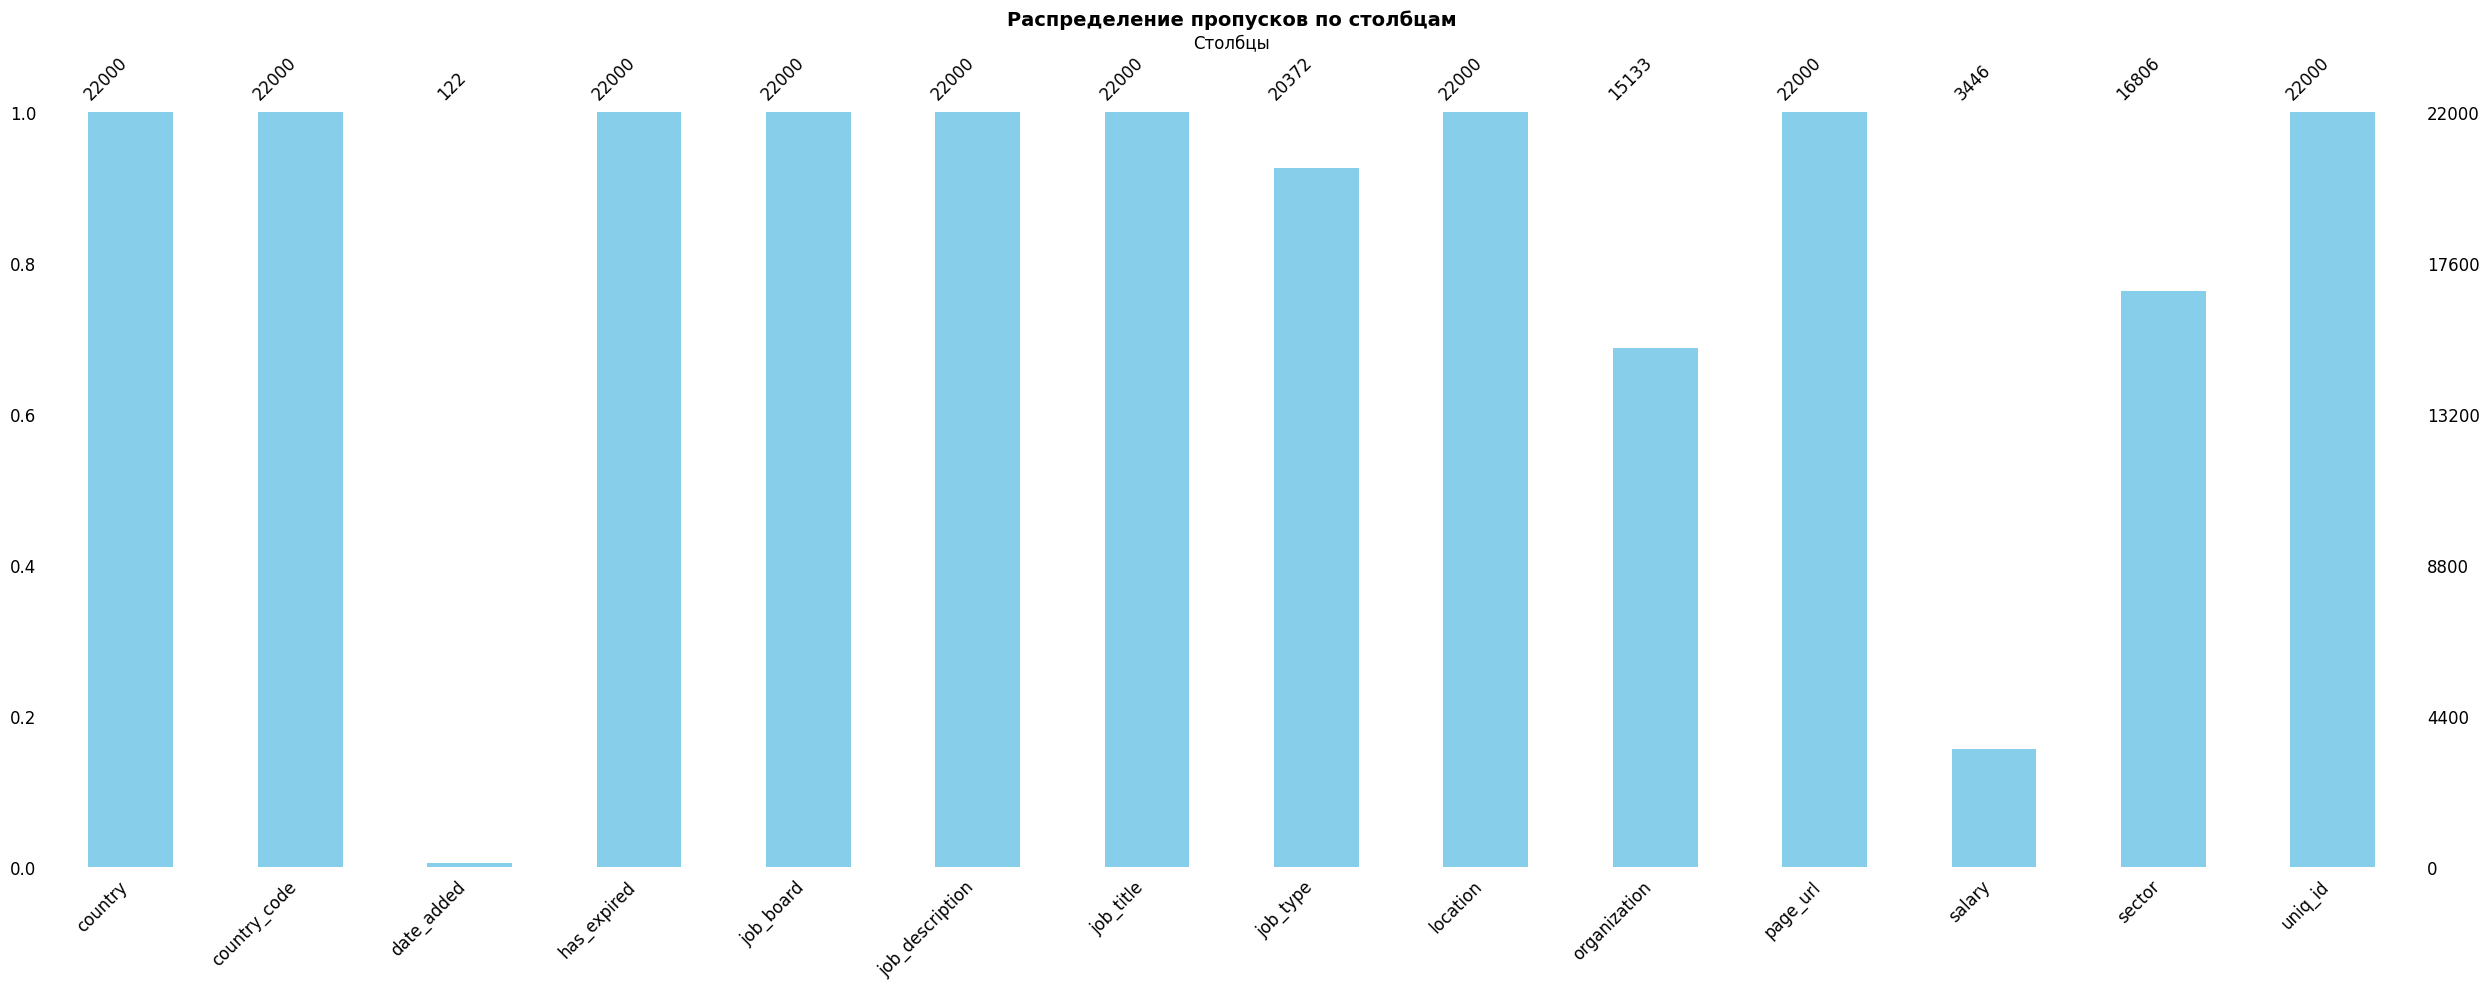

In [4]:
#1 таблица анализа пропусков по столбцам
empty_table = pd.DataFrame({
    'Название столбца': df.columns,
    'Тип данных': df.dtypes.values,
    'Всего ячеек': len(df),
    'Количество пустых ячеек': df.isnull().sum().values,
    'Процент пустых (%)': (df.isnull().sum().values / len(df) * 100).round(2)
})

print(empty_table.to_string(index=False))

#2 Количество строк, где пустыми являются более 75% ячеек

df_temp = df.replace('', pd.NA)
nulls_per_row = df_temp.isnull().sum(axis=1)
threshold = 0.75 * len(df.columns)
rows_with_many_nulls = (nulls_per_row > threshold).sum()

print(f"Всего столбцов в датасете: {len(df.columns)}")
print(f"Пороговое значение (75% от {len(df.columns)}): {threshold:.1f} пустых ячеек")
print(f"Количество строк с >{threshold:.0f} пустых ячеек: {rows_with_many_nulls}")
print(f"Процент от всех строк: {(rows_with_many_nulls / len(df)) * 100:.2f}%")

#3 Визуализация пропусков
plt.figure(figsize=(14, 6))
msno.bar(df, color='skyblue', fontsize=12)
plt.title('Распределение пропусков по столбцам', fontsize=14, fontweight='bold')
plt.xlabel('Столбцы', fontsize=12)
plt.ylabel('Количество непустых значений', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

In [5]:
# Исходный размер
original_rows = len(df)
original_cols = len(df.columns)

print(f"\nИСХОДНЫЙ ДАТАСЕТ:")
print(f"   • Количество строк: {original_rows}")
print(f"   • Количество столбцов: {original_cols}")
print(f"   • Общее количество ячеек: {original_rows * original_cols}")

df_temp = df.replace('', pd.NA)
df_dropped = df_temp.dropna()

# Новый размер
new_rows = len(df_dropped)
new_cols = len(df_dropped.columns)

print(f"\nПОСЛЕ УДАЛЕНИЯ СТРОК С ПУСТЫМИ ЗНАЧЕНИЯМИ:")
print(f"   • Количество строк: {new_rows}")
print(f"   • Количество столбцов: {new_cols}")
print(f"   • Осталось ячеек: {new_rows * new_cols}")

# Потери
rows_lost = original_rows - new_rows
rows_lost_percent = (rows_lost / original_rows) * 100

print(f"\nПОТЕРИ ДАННЫХ:")
print(f"   • Удалено строк: {rows_lost} из {original_rows}")
print(f"   • Потеряно процентов строк: {rows_lost_percent:.1f}%")


ИСХОДНЫЙ ДАТАСЕТ:
   • Количество строк: 22000
   • Количество столбцов: 14
   • Общее количество ячеек: 308000

ПОСЛЕ УДАЛЕНИЯ СТРОК С ПУСТЫМИ ЗНАЧЕНИЯМИ:
   • Количество строк: 5
   • Количество столбцов: 14
   • Осталось ячеек: 70

ПОТЕРИ ДАННЫХ:
   • Удалено строк: 21995 из 22000
   • Потеряно процентов строк: 100.0%


УДАЛЕНИЕ ВСЕХ СТРОК С ПУСТЫМИ ЗНАЧЕНИЯМИ НЕЦЕЛЕСООБРАЗНО!

Причина: будет удалено 100.0% всех строк (21995 из 22000). В датасете останется только 5 строк, а это слишком большая потеря данных для анализа

РЕКОМЕНДАЦИИ:
   1. Не удалять строки с пропусками в salary (18554 пустых, 84.3%)
      — это ценная информация, даже если не у всех вакансий указана зарплата
   
   2. Удалить столбец date_added (21878 пустых, 99.4%)
      — он почти полностью пустой и бесполезен
   
   3. Для job_type (1628 пустых, 7.4%)
      — заполнить пропуски значением "Unknown"
   
   4. Для organization (6867 пустых, 31.2%)
      — оставить как есть или заполнить "Not specified"

### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:
1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?
2. Есть ли такие значения, которые встречаются более чем в одном столбце?
3. Есть ли столбцы, данные в которых не соответствуют названию столбца?

In [11]:
# ВОПРОС 1
print("ВОПРОС 1: СТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ")
cols_with_one_value = []
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count == 1:
        cols_with_one_value.append(col)
        print(f"\n• {col}:")
        print(f"   Уникальных значений: {unique_count}")
        print(f"   Значение: '{df[col].iloc[0]}'")

if cols_with_one_value:
    print(f"\nСТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ: {cols_with_one_value}")
else:
    print("\nСтолбцов с одним значением не найдено")

# ВОПРОС 2

print("\nВОПРОС 2: ЗНАЧЕНИЯ, ВСТРЕЧАЮЩИЕСЯ В НЕСКОЛЬКИХ СТОЛБЦАХ")

pairs_to_check = [
    ('job_title', 'location'),
    ('organization', 'sector'),
    ('job_type', 'employment_type'),
]

for col1, col2 in pairs_to_check:
    if col1 in df.columns and col2 in df.columns:
        common_values = set(df[col1].dropna().unique()) & set(df[col2].dropna().unique())
        if common_values:
            print(f"\n• {col1} и {col2}:")
            print(f"   Общие значения: {list(common_values)[:5]}")
            if len(common_values) > 5:
                print(f"   ... и еще {len(common_values) - 5} значений")

print("\nАнализ: Есть ли город в названии должности?")
sample_df = df[['job_title', 'location']].dropna().head(20)
found_examples = 0
for idx, row in sample_df.iterrows():
    job_title = str(row['job_title']).lower()
    location = str(row['location']).lower()

    if ',' in location:
        city = location.split(',')[0].strip()
    else:
        city = location.split()[0] if location else ''

    if city and city.lower() in job_title.lower() and len(city) > 2:
        found_examples += 1
        if found_examples <= 5:
            print(f"   Пример: в job_title найдено '{city}' из location")

if found_examples > 0:
    print(f"\nНайдено {found_examples} примеров дублирования города в job_title")
else:
    print("Примеров не найдено")

# ВОПРОС 3
print("\nВОПРОС 3: СТОЛБЦЫ С НЕСООТВЕТСТВУЮЩИМИ ДАННЫМИ")

# 1. job_title — содержит город, а должно быть только название должности
def has_city(title):
    if pd.isna(title):
        return False
    return re.search(r'\b in ([A-Z][a-z]+)', str(title)) is not None

bad_titles = df['job_title'].apply(has_city).sum()
print(f"1. job_title: {bad_titles} строк содержат город ('Job in City')")

# 2. salary — текстовый формат, а должен быть числовым
print(f"2. salary: все {df['salary'].notna().sum()} непустых строк — текст, а не числа")

# 3. organization — содержит не только название организации
long_org = (df['organization'].astype(str).str.len() > 100).sum()
print(f"3. organization: {long_org} строк содержат лишние данные (>100 символов)")

# 4. sector — иногда содержит organization вместо сектора
both = df[df['sector'].notna() & df['organization'].notna()]
bad_sector = sum(1 for _, r in both.iterrows() if str(r['sector']) in str(r['organization']))
print(f"4. sector: в {bad_sector} строках указана организация вместо сектора")

# 5. location — содержит не адрес, а мусор
garbage = r'Job Description|Phone|Contact|http|@'
bad_loc = df['location'].astype(str).str.contains(garbage, na=False).sum()
print(f"5. location: {bad_loc} строк содержат мусор вместо адреса")

print("\nВЫВОД: перечисленные столбцы требуют очистки или стандартизации")

ВОПРОС 1: СТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ

• country:
   Уникальных значений: 1
   Значение: 'United States of America'

• country_code:
   Уникальных значений: 1
   Значение: 'US'

• has_expired:
   Уникальных значений: 1
   Значение: 'No'

• job_board:
   Уникальных значений: 1
   Значение: 'jobs.monster.com'

СТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ: ['country', 'country_code', 'has_expired', 'job_board']

ВОПРОС 2: ЗНАЧЕНИЯ, ВСТРЕЧАЮЩИЕСЯ В НЕСКОЛЬКИХ СТОЛБЦАХ

• job_title и location:
   Общие значения: ['Project Manager', 'Field Service Technician', 'Recruiter', 'Software Engineer', 'Senior Project Manager']
   ... и еще 7 значений

• organization и sector:
   Общие значения: ['Electrical/Electronics EngineeringIndustrial/Manufacturing EngineeringMechanical Engineering', 'Retail']

Анализ: Есть ли город в названии должности?
   Пример: в job_title найдено 'madison' из location
   Пример: в job_title найдено 'madison' из location
   Пример: в job_title найдено 'dixon' из location
   Пример: в job_title

### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

In [15]:
print("1. ПРОВЕРКА УНИКАЛЬНОСТИ uniq_id")
print(f"\nВсего строк: {len(df)}")
print(f"Уникальных uniq_id: {df['uniq_id'].nunique()}")

if df['uniq_id'].nunique() == len(df):
    print("Все значения uniq_id уникальны")
else:
    print("Есть дубликаты")

print("\n2. ДРУГИЕ СТОЛБЦЫ С УНИКАЛЬНЫМИ ЗНАЧЕНИЯМИ")
unique_cols = []
for col in df.columns:
    if df[col].nunique() == len(df):
        unique_cols.append(col)
        print(f"• {col}")

if not unique_cols:
    print("Нет других столбцов с полностью уникальными значениями")

print("\n3. ПОИСК ДУБЛИКАТОВ СТРОК (БЕЗ УНИКАЛЬНЫХ СТОЛБЦОВ)")

# Столбцы для проверки (все, кроме уникальных)
check_cols = [col for col in df.columns if col not in unique_cols]

df_check = df[check_cols].replace('', pd.NA)

dup_mask = df_check.duplicated(keep=False)
dup_count = dup_mask.sum()

print(f"Проверяем столбцы: {check_cols[:5]}... (всего {len(check_cols)} шт.)")
print(f"Найдено строк-дубликатов: {dup_count}")

if dup_count > 0:
    dup_groups = df_check[dup_mask].groupby(list(df_check.columns)).ngroups
    print(f"Уникальных групп дубликатов: {dup_groups}")
else:
    print("Дубликатов не найдено")

1. ПРОВЕРКА УНИКАЛЬНОСТИ uniq_id

Всего строк: 22000
Уникальных uniq_id: 22000
Все значения uniq_id уникальны

2. ДРУГИЕ СТОЛБЦЫ С УНИКАЛЬНЫМИ ЗНАЧЕНИЯМИ
• page_url
• uniq_id

3. ПОИСК ДУБЛИКАТОВ СТРОК (БЕЗ УНИКАЛЬНЫХ СТОЛБЦОВ)
Проверяем столбцы: ['country', 'country_code', 'date_added', 'has_expired', 'job_board']... (всего 12 шт.)
Найдено строк-дубликатов: 2078
Уникальных групп дубликатов: 0



ВЫВОДЫ


1. uniq_id: уникален

2. Другие уникальные столбцы: ['page_url', 'uniq_id']

3. Дубликаты строк (без учёта уникальных столбцов):
   найдено 2078 строк-дубликатов


# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).

РАСПРЕДЕЛЕНИЕ ФОРМАТОВ location
Город, Штат Индекс        |  11551 |  52.5%
Город, Штат               |   7186 |  32.7%
Мусор (длинный текст)     |   1174 |   5.3%
Только город              |    922 |   4.2%
Другой формат             |    470 |   2.1%
Город Индекс              |    443 |   2.0%
Только индекс             |    254 |   1.2%


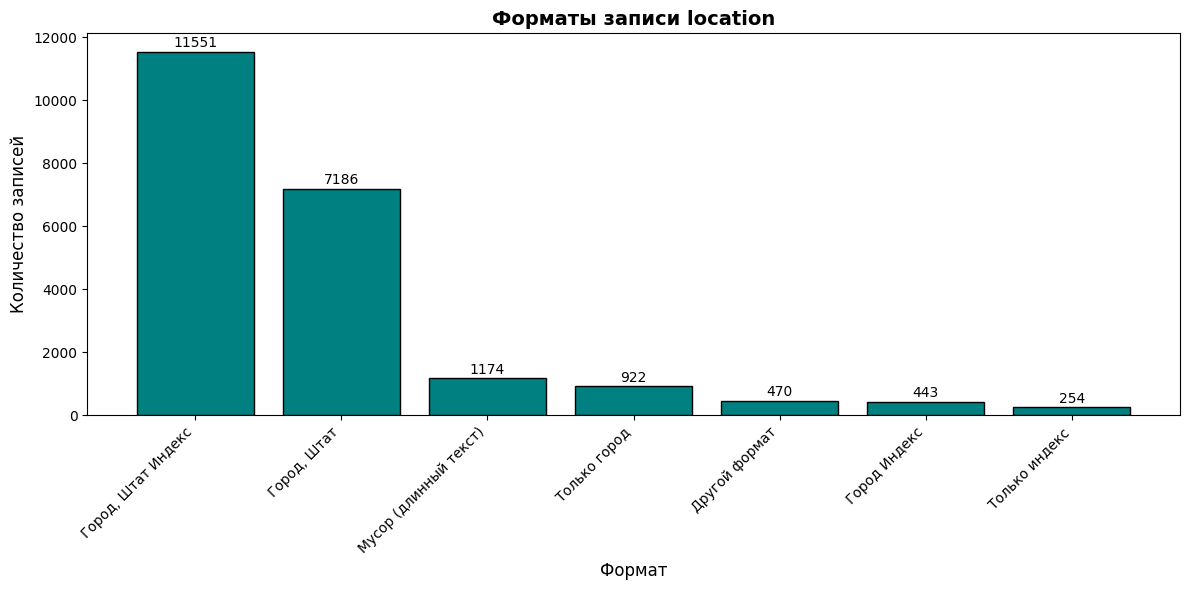


Чаще всего встречается: 'Город, Штат Индекс'
11551 записей (52.5%)


In [18]:
# Список настоящих штатов США (для проверки)
US_STATES = {
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA',
    'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
    'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
    'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
    'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY',
    'DC', 'PR', 'GU', 'VI', 'AS', 'MP'
}

patterns = {
    'Город, Штат Индекс': r'([A-Za-z\s]+),\s*([A-Z]{2})\s*(\d{5})',
    'Город, Штат': r'([A-Za-z\s]+),\s*([A-Z]{2})$',
    'Город Индекс': r'([A-Za-z\s]+)\s+(\d{5})$',
    'Только город': r'^[A-Za-z\s]+$',
    'Только индекс': r'^\d{5}$',
}

def get_location_format(location):
    if pd.isna(location) or location == '':
        return 'Пусто'

    loc = str(location).strip()

    for name, pattern in patterns.items():
        if re.search(pattern, loc):
            if 'Штат' in name:
                state_match = re.search(r'([A-Z]{2})', loc)
                if state_match and state_match.group(1) not in US_STATES:
                    continue
            return name

    if len(loc) > 200:
        return 'Мусор (длинный текст)'
    return 'Другой формат'

df['loc_format'] = df['location'].apply(get_location_format)

format_counts = df['loc_format'].value_counts()

print("РАСПРЕДЕЛЕНИЕ ФОРМАТОВ location")
for fmt, cnt in format_counts.items():
    print(f"{fmt:25} | {cnt:6} | {cnt/len(df)*100:5.1f}%")

# Визуализация
plt.figure(figsize=(12, 6))
bars = plt.bar(format_counts.index, format_counts.values, color='teal', edgecolor='black')
plt.title('Форматы записи location', fontsize=14, fontweight='bold')
plt.xlabel('Формат', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Какой формат встречается чаще всего?
most_common = format_counts.index[0]
print(f"\nЧаще всего встречается: '{most_common}'")
print(f"{format_counts[most_common]} записей ({format_counts[most_common]/len(df)*100:.1f}%)")

#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, преобразуйте их в целочисленный формат.

In [20]:
print("ШАГ 1: ОТДЕЛЯЕМ МУСОРНЫЕ СТРОКИ")

garbage_mask = df['loc_format'].isin(['Другой формат', 'Мусор (длинный текст)', 'Пусто'])
garbage_df = df[garbage_mask].copy()
clean_df = df[~garbage_mask].copy()

print(f"Чистые строки (можно обработать): {len(clean_df)}")
print(f"Мусорные строки (отдельный датасет): {len(garbage_df)}")

garbage_df.to_csv('garbage_locations.csv', index=False)
print("Мусорные строки сохранены в 'garbage_locations.csv'")

print("ШАГ 2: ИЗВЛЕКАЕМ ГОРОД, ШТАТ, ИНДЕКС")

def split_location(location):
    if pd.isna(location) or location == '':
        return None, None, None

    loc = str(location).strip()

    # 1. Город, Штат, Индекс (пример: "Madison, WI 53702")
    match = re.search(r'([A-Za-z\s\.-]+),\s*([A-Z]{2})\s*(\d{5})', loc)
    if match:
        return match.group(1).strip(), match.group(2), match.group(3)

    # 2. Город, Штат (пример: "Dixon, CA")
    match = re.search(r'([A-Za-z\s\.-]+),\s*([A-Z]{2})$', loc)
    if match:
        return match.group(1).strip(), match.group(2), None

    # 3. Город Индекс (пример: "Wadesboro 28170")
    match = re.search(r'([A-Za-z\s\.-]+)\s+(\d{5})$', loc)
    if match:
        return match.group(1).strip(), None, match.group(2)

    # 4. Штат Индекс (пример: "NY 10013")
    match = re.search(r'^([A-Z]{2})\s+(\d{5})$', loc)
    if match:
        return None, match.group(1), match.group(2)

    # 5. Только город
    if re.match(r'^[A-Za-z\s]+$', loc):
        return loc, None, None

    # 6. Только штат
    if re.match(r'^[A-Z]{2}$', loc):
        return None, loc, None

    # 7. Только индекс
    if re.match(r'^\d{5}$', loc):
        return None, None, loc

    return None, None, None

# Применяем к чистым строкам
clean_df[['city', 'state', 'zip_code']] = clean_df['location'].apply(
    lambda x: pd.Series(split_location(x))
)

# Преобразуем индекс в число
clean_df['zip_code'] = pd.to_numeric(clean_df['zip_code'], errors='coerce').astype('Int64')

# Добавляем результаты в исходный df
df['city'] = None
df['state'] = None
df['zip_code'] = None
df.loc[clean_df.index, 'city'] = clean_df['city']
df.loc[clean_df.index, 'state'] = clean_df['state']
df.loc[clean_df.index, 'zip_code'] = clean_df['zip_code']

print(f"Городов извлечено: {df['city'].notna().sum()}")
print(f"Штатов извлечено: {df['state'].notna().sum()}")
print(f"Индексов извлечено: {df['zip_code'].notna().sum()}")

ШАГ 1: ОТДЕЛЯЕМ МУСОРНЫЕ СТРОКИ
Чистые строки (можно обработать): 20356
Мусорные строки (отдельный датасет): 1644
Мусорные строки сохранены в 'garbage_locations.csv'
ШАГ 2: ИЗВЛЕКАЕМ ГОРОД, ШТАТ, ИНДЕКС
Городов извлечено: 20102
Штатов извлечено: 18808
Индексов извлечено: 12248


Рассмотрите отложенную часть выборки (ту, где не удалось данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

In [23]:
print("ШАГ 3: АНАЛИЗ МУСОРНЫХ СТРОК")

# Список настоящих штатов США
US_STATES = {
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA',
    'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
    'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
    'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
    'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY',
    'DC', 'PR', 'GU', 'VI', 'AS', 'MP'
}

print(f"Всего мусорных строк: {len(garbage_df)}")

def extract_from_garbage(location):
    """Пытается извлечь город, штат и индекс из мусорных строк"""
    if pd.isna(location):
        return None, None, None

    loc = str(location)

    # Ищем индекс (5 цифр) — это самое надёжное
    zip_match = re.search(r'\b(\d{5})\b', loc)
    zip_code = zip_match.group(1) if zip_match else None

    # Ищем штат (две заглавные буквы) — но проверяем, что это не часть слова
    state_match = re.search(r'\b([A-Z]{2})\b', loc)
    state = None
    if state_match:
        potential_state = state_match.group(1)
        if potential_state in US_STATES:
            state = potential_state

    # Ищем город — слово с заглавной буквы, не слишком длинное
    city_match = re.search(r'\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)\b', loc)
    city = city_match.group(1) if city_match else None

    # Если "город" подозрительно длинный или содержит мусор — не берём
    if city and (len(city) > 30 or re.search(r'Job|Description|Phone|Contact', city)):
        city = None

    return city, state, zip_code

garbage_df[['city_g', 'state_g', 'zip_g']] = garbage_df['location'].apply(
    lambda x: pd.Series(extract_from_garbage(x))
)

# Преобразуем индекс в число
garbage_df['zip_g'] = pd.to_numeric(garbage_df['zip_g'], errors='coerce').astype('Int64')

print("\nРЕЗУЛЬТАТЫ ИЗВЛЕЧЕНИЯ ИЗ МУСОРА")
print(f"Удалось извлечь индекс: {garbage_df['zip_g'].notna().sum()} строк")
print(f"Удалось извлечь штат: {garbage_df['state_g'].notna().sum()} строк")
print(f"Удалось извлечь город: {garbage_df['city_g'].notna().sum()} строк")

df['city_final'] = df['city']
df['state_final'] = df['state']
df['zip_final'] = df['zip_code']

for idx in garbage_df.index:
    if pd.notna(garbage_df.loc[idx, 'city_g']):
        df.loc[idx, 'city_final'] = garbage_df.loc[idx, 'city_g']
    if pd.notna(garbage_df.loc[idx, 'state_g']):
        df.loc[idx, 'state_final'] = garbage_df.loc[idx, 'state_g']
    if pd.notna(garbage_df.loc[idx, 'zip_g']):
        df.loc[idx, 'zip_final'] = garbage_df.loc[idx, 'zip_g']

print("\nИТОГОВЫЕ РЕЗУЛЬТАТЫ ПО ВСЕМУ ДАТАСЕТУ")
print(f"Город: {df['city_final'].notna().sum()} строк")
print(f"Штат: {df['state_final'].notna().sum()} строк")
print(f"Индекс: {df['zip_final'].notna().sum()} строк")

ШАГ 3: АНАЛИЗ МУСОРНЫХ СТРОК
Всего мусорных строк: 1644

РЕЗУЛЬТАТЫ ИЗВЛЕЧЕНИЯ ИЗ МУСОРА
Удалось извлечь индекс: 247 строк
Удалось извлечь штат: 520 строк
Удалось извлечь город: 1255 строк

ИТОГОВЫЕ РЕЗУЛЬТАТЫ ПО ВСЕМУ ДАТАСЕТУ
Город: 21357 строк
Штат: 19328 строк
Индекс: 12495 строк


ВЫВОДЫ ПО МУСОРНЫМ СТРОКАМ

1. Всего мусорных строк: 1644 шт. (7.5% от датасета)

2. Что удалось извлечь из мусора:

   • Индекс (5 цифр) — 247 строк

   • Штат (2 буквы) — 520 строк
   
   • Город — 1255 строк

3. Рекомендация: использовать для анализа location только чистые строки
   (20356 шт.), а мусорные строки исключить.

### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.

РАСПРЕДЕЛЕНИЕ ФОРМАТОВ salary
Нет данных                |  18554 |  84.3%
диапазон_год              |   1641 |   7.5%
диапазон_час              |   1032 |   4.7%
Другой формат             |    361 |   1.6%
одинарная_без_периода     |    290 |   1.3%
up_to                     |    101 |   0.5%
диапазон_месяц            |     17 |   0.1%
диапазон_неделя           |      4 |   0.0%


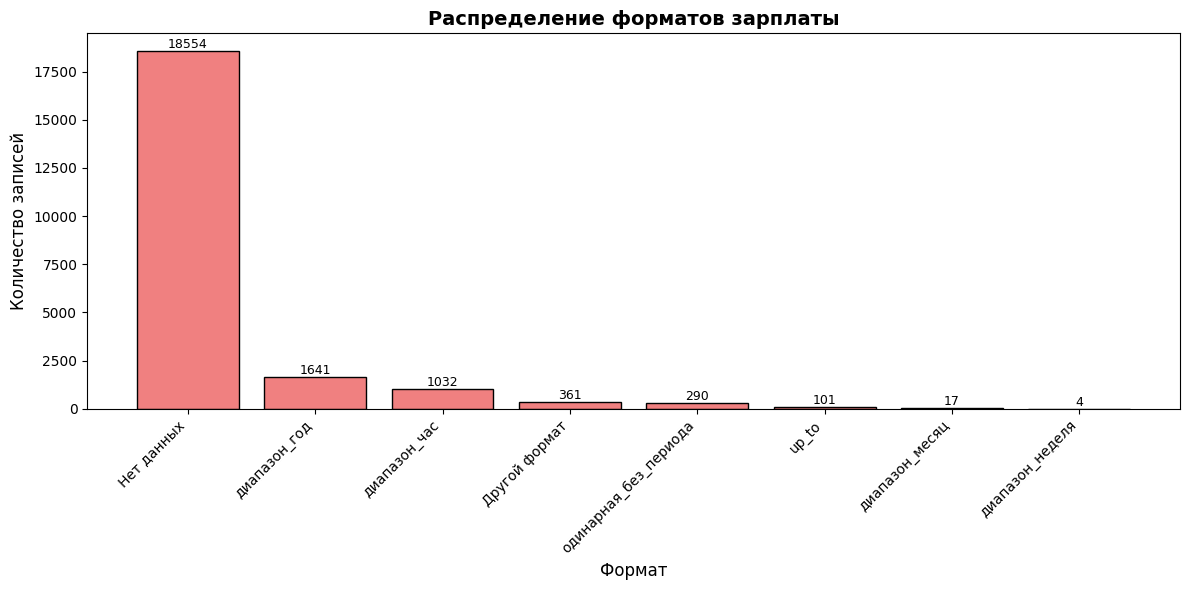

Чаще всего встречается формат: 'диапазон_год'
1641 записей (7.5%)

Всего записей с зарплатой: 3446
Пустых записей: 18554 (84.3%)


In [3]:
salary_patterns = {
    'диапазон_год': r'(\d[\d,\.]+)\s*-\s*(\d[\d,\.]+)\s*\$\s*/year',
    'диапазон_час': r'(\d[\d,\.]+)\s*-\s*(\d[\d,\.]+)\s*\$\s*/hour',
    'диапазон_месяц': r'(\d[\d,\.]+)\s*-\s*(\d[\d,\.]+)\s*\$\s*/month',
    'диапазон_неделя': r'(\d[\d,\.]+)\s*-\s*(\d[\d,\.]+)\s*\$\s*/week',
    'одинарная_год': r'\$?(\d[\d,\.]+)\s*(?:\+)?\s*\$\s*/year',
    'одинарная_час': r'\$?(\d[\d,\.]+)\s*(?:\+)?\s*\$\s*/hour',
    'одинарная_месяц': r'\$?(\d[\d,\.]+)\s*(?:\+)?\s*\$\s*/month',
    'одинарная_неделя': r'\$?(\d[\d,\.]+)\s*(?:\+)?\s*\$\s*/week',
    'up_to': r'Up to \$?(\d[\d,\.]+)',
    'одинарная_без_периода': r'\$?(\d[\d,\.]+)',
}

def get_salary_format(salary):
    if pd.isna(salary) or salary == '':
        return 'Нет данных'

    salary = str(salary).strip()

    for name, pattern in salary_patterns.items():
        if re.search(pattern, salary, re.IGNORECASE):
            return name

    return 'Другой формат'

df['salary_format'] = df['salary'].apply(get_salary_format)

format_counts = df['salary_format'].value_counts()


print("РАСПРЕДЕЛЕНИЕ ФОРМАТОВ salary")
for fmt, cnt in format_counts.items():
    print(f"{fmt:25} | {cnt:6} | {cnt/len(df)*100:5.1f}%")

# Визуализация
plt.figure(figsize=(12, 6))
bars = plt.bar(format_counts.index, format_counts.values, color='lightcoral', edgecolor='black')
plt.title('Распределение форматов зарплаты', fontsize=14, fontweight='bold')
plt.xlabel('Формат', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Какой формат встречается чаще всего (среди непустых)
non_empty_counts = format_counts[format_counts.index != 'Нет данных']
if len(non_empty_counts) > 0:
    most_common = non_empty_counts.index[0]
    print(f"Чаще всего встречается формат: '{most_common}'")
    print(f"{non_empty_counts[most_common]} записей ({non_empty_counts[most_common]/len(df)*100:.1f}%)")

print(f"\nВсего записей с зарплатой: {df['salary'].notna().sum()}")
print(f"Пустых записей: {df['salary'].isna().sum()} ({df['salary'].isna().sum()/len(df)*100:.1f}%)")

#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

РЕЗУЛЬТАТЫ ПАРСИНГА salary
Минимальная зарплата извлечена для: 2984 строк
Максимальная зарплата извлечена для: 2804 строк
Период извлечён для: 2694 строк
СТАТИСТИКА ПО ПЕРИОДАМ
                   mean    median  count
salary_period                           
hour             206.03     16.00   1032
month           6048.41   4905.22     17
week             553.00    600.00      4
year           59102.73  55000.00   1641


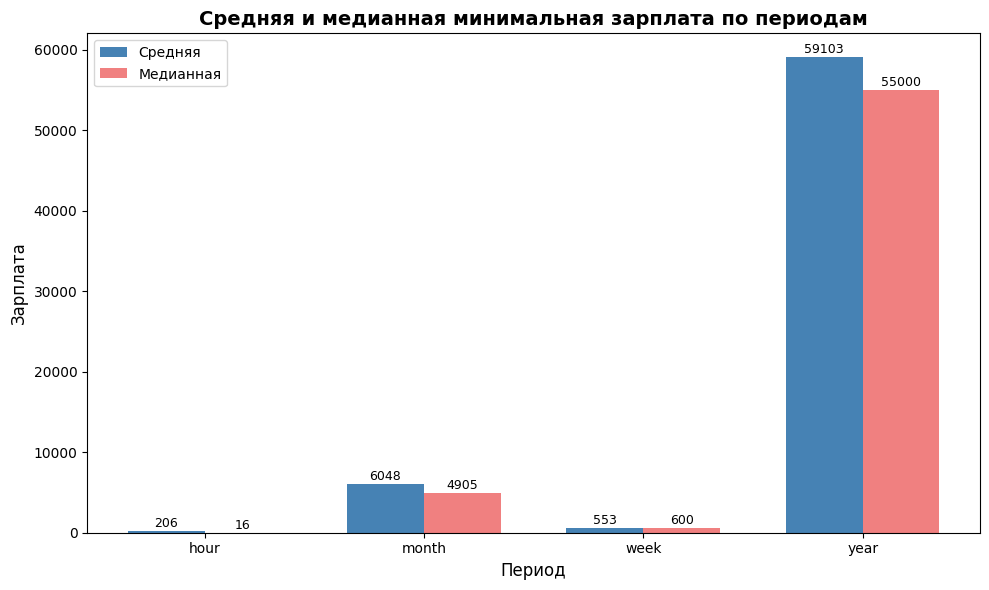

In [5]:
def parse_salary(salary):
    if pd.isna(salary) or salary == '':
        return None, None, None

    sal = str(salary).strip()

    # 1. Диапазон с периодом (пример: "10.00 - 20.00 $ /hour")
    match = re.search(r'(\d[\d,\.]+)\s*-\s*(\d[\d,\.]+)\s*\$\s*/(year|hour|month|week)', sal, re.IGNORECASE)
    if match:
        min_sal = float(match.group(1).replace(',', ''))
        max_sal = float(match.group(2).replace(',', ''))
        period = match.group(3).lower()
        return min_sal, max_sal, period

    # 2. Одинарная с периодом (пример: "$10.00 /hour")
    match = re.search(r'\$?(\d[\d,\.]+)\s*(?:\+)?\s*\$\s*/(year|hour|month|week)', sal, re.IGNORECASE)
    if match:
        min_sal = float(match.group(1).replace(',', ''))
        period = match.group(2).lower()
        return min_sal, None, period

    # 3. Up to (пример: "Up to $20,000.00")
    match = re.search(r'Up to \$?(\d[\d,\.]+)', sal, re.IGNORECASE)
    if match:
        max_sal = float(match.group(1).replace(',', ''))
        return None, max_sal, None

    # 4. Диапазон без периода (пример: "80,000 - 95,000 $")
    match = re.search(r'(\d[\d,\.]+)\s*-\s*(\d[\d,\.]+)\s*\$', sal)
    if match:
        min_sal = float(match.group(1).replace(',', ''))
        max_sal = float(match.group(2).replace(',', ''))
        return min_sal, max_sal, None

    # 5. Одинарная без периода (пример: "$10.00")
    match = re.search(r'\$?(\d[\d,\.]+)', sal)
    if match:
        min_sal = float(match.group(1).replace(',', ''))
        return min_sal, None, None

    return None, None, None

df[['min_salary', 'max_salary', 'salary_period']] = df['salary'].apply(
    lambda x: pd.Series(parse_salary(x))
)

print("РЕЗУЛЬТАТЫ ПАРСИНГА salary")
print(f"Минимальная зарплата извлечена для: {df['min_salary'].notna().sum()} строк")
print(f"Максимальная зарплата извлечена для: {df['max_salary'].notna().sum()} строк")
print(f"Период извлечён для: {df['salary_period'].notna().sum()} строк")

print("СТАТИСТИКА ПО ПЕРИОДАМ")

period_stats = df.groupby('salary_period')['min_salary'].agg(['mean', 'median', 'count']).round(2)
print(period_stats)

# Визуализация
if not period_stats.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    x = range(len(period_stats))
    width = 0.35

    bars1 = ax.bar([i - width/2 for i in x], period_stats['mean'], width, label='Средняя', color='steelblue')
    bars2 = ax.bar([i + width/2 for i in x], period_stats['median'], width, label='Медианная', color='lightcoral')

    ax.set_xlabel('Период', fontsize=12)
    ax.set_ylabel('Зарплата', fontsize=12)
    ax.set_title('Средняя и медианная минимальная зарплата по периодам', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(period_stats.index)
    ax.legend()

    # Подписи на столбцах
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 100, f'{height:.0f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 100, f'{height:.0f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

ВЫВОДЫ

1. Больше всего данных о зарплате с указанием периода за год и за час.
2. Средняя почасовая зарплата 200 значительно ниже средней годовой 59 000.
3. Медианная зарплата ниже средней во всех периодах, что говорит о наличии
   высоких зарплат, сдвигающих среднее значение вверх.
4. Данных за месяц и неделю очень мало, выводы по ним нерепрезентативны.


#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

ШАГ 1: АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ ПО ПЕРИОДАМ
year: 1641 записей, среднее = 59102.73, медиана = 55000.00
hour: 1032 записей, среднее = 206.03, медиана = 16.00
month: 17 записей, среднее = 6048.41, медиана = 4905.22
week: 4 записей, среднее = 553.00, медиана = 600.00


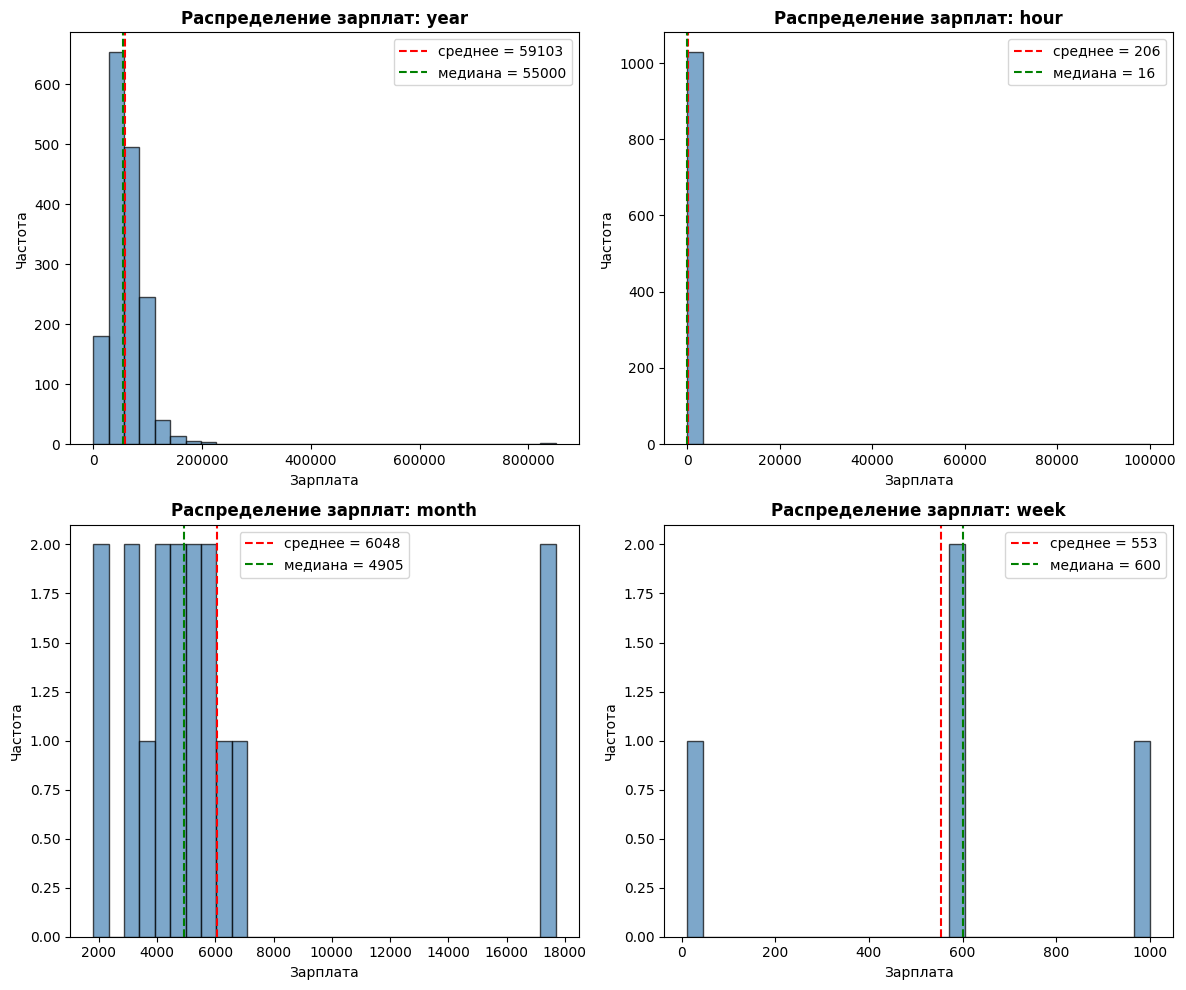

ШАГ 2: ВОССТАНАВЛИВАЕМ ПЕРИОД ДЛЯ ЗАРПЛАТ БЕЗ ПЕРИОДА
Строк с зарплатой, но без периода: 290
Восстановлено периодов: 279
Осталось без периода (спорные случаи): 11
ИТОГОВАЯ СТАТИСТИКА ПО ПЕРИОДАМ
year       |   1729 записей
hour       |   1189 записей
week       |     29 записей
month      |     26 записей


In [7]:
print("ШАГ 1: АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ ПО ПЕРИОДАМ")

# Собираем данные по каждому периоду
period_data = {}
for period in ['year', 'hour', 'month', 'week']:
    data = df[df['salary_period'] == period]['min_salary'].dropna()
    if len(data) > 0:
        period_data[period] = data
        print(f"{period}: {len(data)} записей, среднее = {data.mean():.2f}, медиана = {data.median():.2f}")

# Строим гистограммы для каждого периода
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (period, data) in enumerate(period_data.items()):
    ax = axes[i]
    ax.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Распределение зарплат: {period}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Зарплата', fontsize=10)
    ax.set_ylabel('Частота', fontsize=10)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'среднее = {data.mean():.0f}')
    ax.axvline(data.median(), color='green', linestyle='--', label=f'медиана = {data.median():.0f}')
    ax.legend()

# Скрываем пустой график (если есть)
for j in range(i+1, 4):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

print("ШАГ 2: ВОССТАНАВЛИВАЕМ ПЕРИОД ДЛЯ ЗАРПЛАТ БЕЗ ПЕРИОДА")

# Находим строки, где есть зарплата, но нет периода
missing_mask = df['min_salary'].notna() & df['salary_period'].isna()
print(f"Строк с зарплатой, но без периода: {missing_mask.sum()}")

def assign_period(salary):
    """
    Определяет период по ближайшему среднему значению
    Если разница с ближайшим и вторым ближайшим периодом меньше 20% — не определяем
    """
    if pd.isna(salary):
        return None

    # Вычисляем расстояние до среднего каждого периода
    distances = {}
    for period, data in period_data.items():
        mean_val = data.mean()
        distances[period] = abs(salary - mean_val)

    # Сортируем по расстоянию
    sorted_periods = sorted(distances.items(), key=lambda x: x[1])

    best_period = sorted_periods[0][0]
    best_dist = sorted_periods[0][1]

    # Проверяем спорный случай: если второй период почти так же близок
    if len(sorted_periods) > 1:
        second_dist = sorted_periods[1][1]
        if second_dist / best_dist < 1.2:  # менее 20% разницы
            return None  # спорный случай — не определяем

    return best_period

df['salary_period_filled'] = df['salary_period'].copy()
df.loc[missing_mask, 'salary_period_filled'] = df.loc[missing_mask, 'min_salary'].apply(assign_period)

filled_count = (missing_mask & df['salary_period_filled'].notna()).sum()
print(f"Восстановлено периодов: {filled_count}")
print(f"Осталось без периода (спорные случаи): {missing_mask.sum() - filled_count}")


print("ИТОГОВАЯ СТАТИСТИКА ПО ПЕРИОДАМ")
final_counts = df['salary_period_filled'].value_counts()
for period, count in final_counts.items():
    print(f"{period:10} | {count:6} записей")

ВЫВОДЫ

1. Исходно период был указан для 2694 строк
2. После восстановления период определён для 2973 строк
3. Удалось восстановить 279 пропущенных периодов

4. Спорные случаи (зарплаты, одинаково близкие к нескольким периодам):
   11 строк остались без периода

5. Рекомендация: при анализе использовать столбец salary_period_filled

### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

АНАЛИЗ ФОРМАТОВ job_type
Всего записей: 22000
Уникальных форматов: 39
Пустых значений: 1628 (7.4%)
ТОП-15 ФОРМАТОВ job_type
Full Time                           |   6757 | 30.71%
Full Time Employee                  |   6617 | 30.08%
Full Time, Employee                 |   3360 | 15.27%
Full Time Temporary/Contract/Project |   1062 |  4.83%
Full Time, Temporary/Contract/Project |    533 |  2.42%
Full Time , Employee                |    406 |  1.85%
Part Time Employee                  |    382 |  1.74%
Part Time                           |    329 |  1.50%
Part Time, Employee                 |    196 |  0.89%
Temporary/Contract/Project          |    193 |  0.88%
Employee                            |    147 |  0.67%
Full Time / Employee                |    121 |  0.55%
Full Time , Temporary/Contract/Project |     56 |  0.25%
Part Time, Temporary/Contract/Project |     34 |  0.15%
Per Diem, Employee                  |     29 |  0.13%


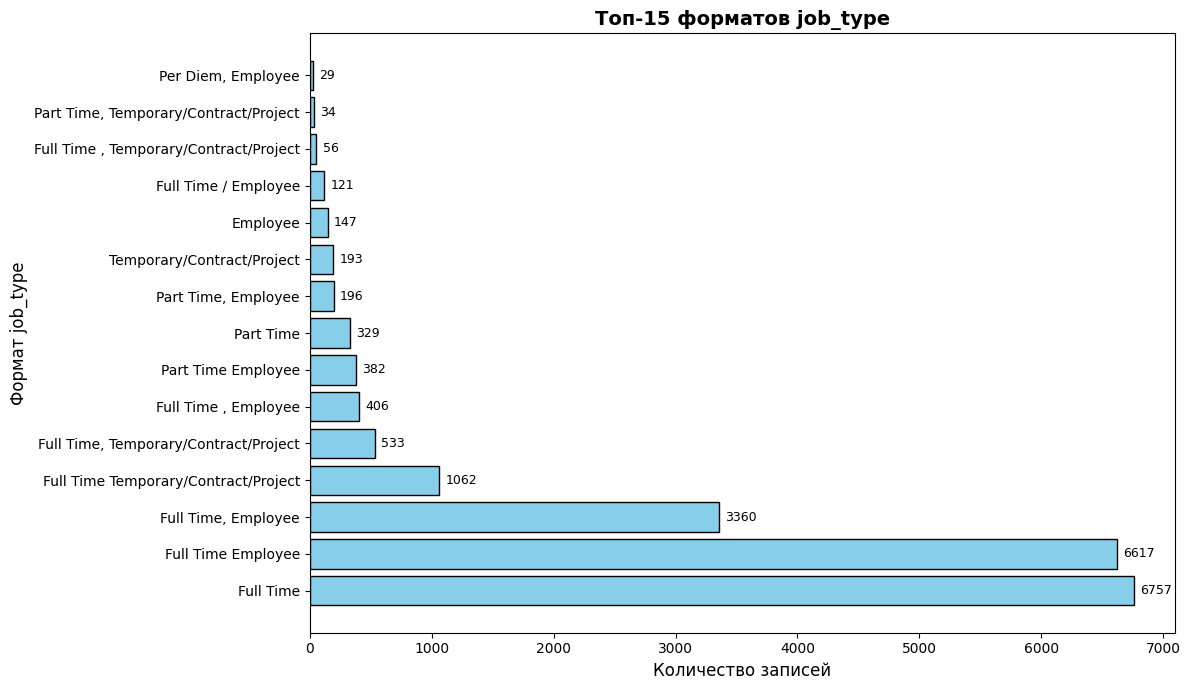

In [10]:
print("АНАЛИЗ ФОРМАТОВ job_type")

print(f"Всего записей: {len(df)}")
print(f"Уникальных форматов: {df['job_type'].nunique()}")
print(f"Пустых значений: {df['job_type'].isna().sum()} ({df['job_type'].isna().sum()/len(df)*100:.1f}%)")

print("ТОП-15 ФОРМАТОВ job_type")

top_formats = df['job_type'].value_counts().head(15)
for fmt, cnt in top_formats.items():
    print(f"{fmt:35} | {cnt:6} | {cnt/len(df)*100:5.2f}%")

# Визуализация
plt.figure(figsize=(12, 7))
bars = plt.barh(range(len(top_formats)), top_formats.values, color='skyblue', edgecolor='black')
plt.yticks(range(len(top_formats)), top_formats.index)
plt.xlabel('Количество записей', fontsize=12)
plt.ylabel('Формат job_type', fontsize=12)
plt.title('Топ-15 форматов job_type', fontsize=14, fontweight='bold')

# Добавляем подписи на столбцах
for i, (fmt, cnt) in enumerate(top_formats.items()):
    plt.text(cnt + 50, i, str(cnt), va='center', fontsize=9)

plt.tight_layout()
plt.show()

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

ШАГ 1: ПРИВОДИМ К ЕДИНОМУ ФОРМАТУ
Исходное количество уникальных форматов: 39
После стандартизации: 8
РАСПРЕДЕЛЕНИЕ ПОСЛЕ СТАНДАРТИЗАЦИИ
Full Time Employee        |  19088 | 86.76%
Full Time Contract        |   1847 |  8.40%
Part Time Employee        |    933 |  4.24%
Per Diem Employee         |     63 |  0.29%
Part Time Contract        |     57 |  0.26%
Full Time Intern          |      5 |  0.02%
Per Diem Contract         |      4 |  0.02%
Part Time Intern          |      3 |  0.01%


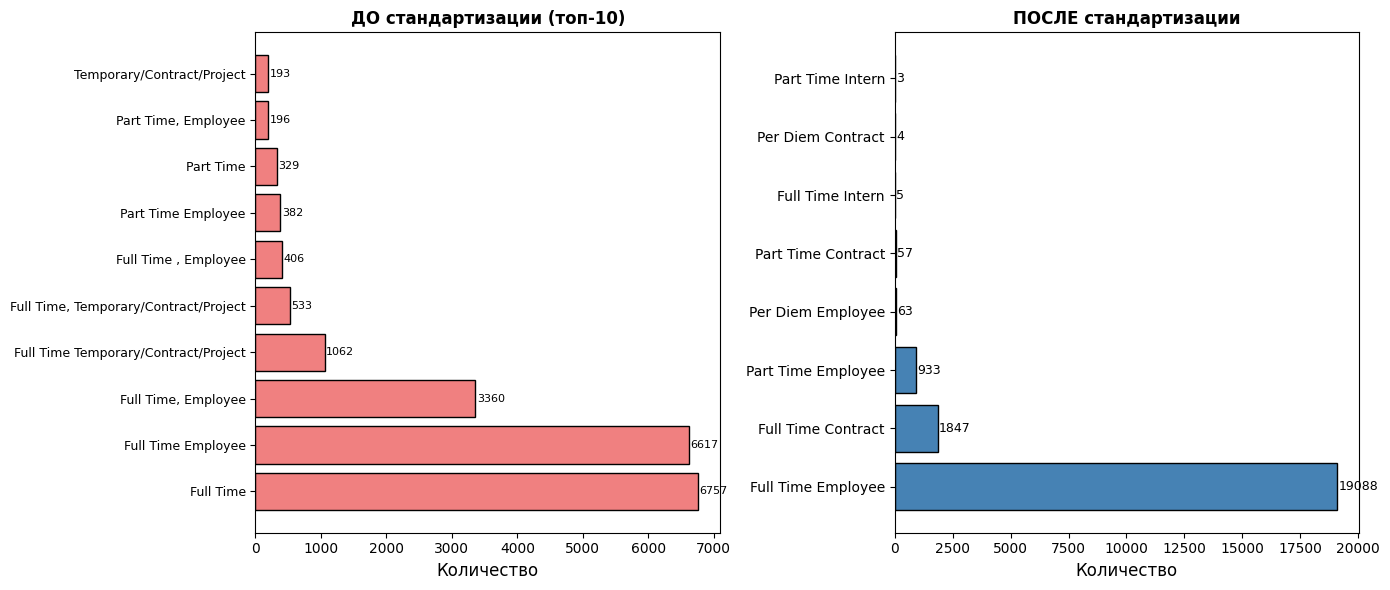

In [12]:
print("ШАГ 1: ПРИВОДИМ К ЕДИНОМУ ФОРМАТУ")
def standardize_job_type(jt):
    """
    Приводит job_type к единому формату: "Полнота Тип"
    Например: "Full Time Employee", "Part Time Contract" и т.д.
    """
    if pd.isna(jt):
        return 'Full Time Employee'  # по умолчанию

    jt = str(jt).strip()
    jt_lower = jt.lower()

    # Определяем полноту занятости
    if re.search(r'part[\s\-]?time', jt_lower):
        fullness = 'Part Time'
    elif re.search(r'per diem', jt_lower):
        fullness = 'Per Diem'
    elif re.search(r'full[\s\-]?time', jt_lower):
        fullness = 'Full Time'
    else:
        fullness = 'Full Time'  # значение по умолчанию

    # Определяем тип занятости
    if re.search(r'intern', jt_lower):
        type_val = 'Intern'
    elif re.search(r'employee', jt_lower):
        type_val = 'Employee'
    elif re.search(r'contract|temporary|project', jt_lower):
        type_val = 'Contract'
    else:
        type_val = 'Employee'  # значение по умолчанию

    return f"{fullness} {type_val}"

df['job_type_std'] = df['job_type'].apply(standardize_job_type)

print(f"Исходное количество уникальных форматов: {df['job_type'].nunique()}")
print(f"После стандартизации: {df['job_type_std'].nunique()}")


print("РАСПРЕДЕЛЕНИЕ ПОСЛЕ СТАНДАРТИЗАЦИИ")

std_counts = df['job_type_std'].value_counts()
for fmt, cnt in std_counts.items():
    print(f"{fmt:25} | {cnt:6} | {cnt/len(df)*100:5.2f}%")

# Визуализация: сравнение "до" и "после"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# До стандартизации (топ-10)
top_before = df['job_type'].value_counts().head(10)
axes[0].barh(range(len(top_before)), top_before.values, color='lightcoral', edgecolor='black')
axes[0].set_yticks(range(len(top_before)))
axes[0].set_yticklabels(top_before.index, fontsize=9)
axes[0].set_xlabel('Количество', fontsize=12)
axes[0].set_title('ДО стандартизации (топ-10)', fontsize=12, fontweight='bold')

for i, (fmt, cnt) in enumerate(top_before.items()):
    axes[0].text(cnt + 20, i, str(cnt), va='center', fontsize=8)

# После стандартизации
axes[1].barh(range(len(std_counts)), std_counts.values, color='steelblue', edgecolor='black')
axes[1].set_yticks(range(len(std_counts)))
axes[1].set_yticklabels(std_counts.index)
axes[1].set_xlabel('Количество', fontsize=12)
axes[1].set_title('ПОСЛЕ стандартизации', fontsize=12, fontweight='bold')

for i, (fmt, cnt) in enumerate(std_counts.items()):
    axes[1].text(cnt + 50, i, str(cnt), va='center', fontsize=9)

plt.tight_layout()
plt.show()

Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.

ШАГ 1: РАЗДЕЛЯЕМ НА ПОЛНОТУ И ТИП ЗАНЯТОСТИ
РЕЗУЛЬТАТЫ РАЗДЕЛЕНИЯ

Полнота занятости:
   Full Time    |  20940 | 95.18%
   Part Time    |    993 |  4.51%
   Per Diem     |     67 |  0.30%

Тип занятости:
   Employee     |  20084 | 91.29%
   Contract     |   1908 |  8.67%
   Intern       |      8 |  0.04%

Кросс-таблица (полнота × тип):
job_emp_type  Contract  Employee  Intern
job_fullness                            
Full Time         1847     19088       5
Part Time           57       933       3
Per Diem             4        63       0
ШАГ 2: ВИЗУАЛИЗАЦИЯ (СТЕКОВАЯ ГРУППИРОВКА)


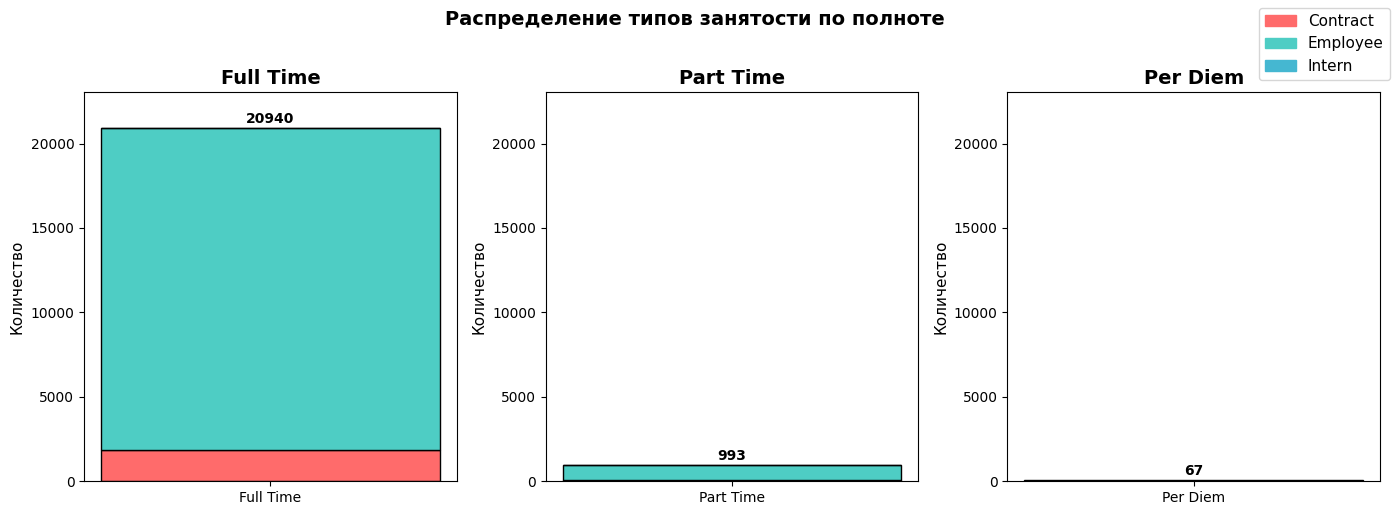


ВЫВОДЫ

1. Большинство вакансий — Full Time Employee (19088 шт., 86.8%)

2. Full Time Contract занимает второе место (1847 шт., 8.4%)

3. Part Time и Per Diem встречаются значительно реже

4. Intern встречается крайне редко (всего 8 записей)

5. Пустые значения были заполнены значениями по умолчанию (Full Time Employee)



In [13]:
print("ШАГ 1: РАЗДЕЛЯЕМ НА ПОЛНОТУ И ТИП ЗАНЯТОСТИ")

def split_job_type(job_type):
    """
    Разделяет job_type на две составляющие:
    - полнота занятости (Full Time / Part Time / Per Diem)
    - тип занятости (Employee / Intern / Contract)
    """
    if pd.isna(job_type):
        return 'Full Time', 'Employee'

    jt = str(job_type).strip()
    jt_lower = jt.lower()

    # 1. Определяем полноту занятости
    if re.search(r'part[\s\-]?time', jt_lower):
        fullness = 'Part Time'
    elif re.search(r'per diem', jt_lower):
        fullness = 'Per Diem'
    elif re.search(r'full[\s\-]?time', jt_lower):
        fullness = 'Full Time'
    else:
        fullness = 'Full Time'

    # 2. Определяем тип занятости
    if re.search(r'intern', jt_lower):
        emp_type = 'Intern'
    elif re.search(r'employee', jt_lower):
        emp_type = 'Employee'
    elif re.search(r'contract|temporary|project', jt_lower):
        emp_type = 'Contract'
    else:
        emp_type = 'Employee'

    return fullness, emp_type

# Применяем
df[['job_fullness', 'job_emp_type']] = df['job_type'].apply(
    lambda x: pd.Series(split_job_type(x))
)

print("РЕЗУЛЬТАТЫ РАЗДЕЛЕНИЯ")

print("\nПолнота занятости:")
fullness_counts = df['job_fullness'].value_counts()
for val, cnt in fullness_counts.items():
    print(f"   {val:12} | {cnt:6} | {cnt/len(df)*100:5.2f}%")

print("\nТип занятости:")
type_counts = df['job_emp_type'].value_counts()
for val, cnt in type_counts.items():
    print(f"   {val:12} | {cnt:6} | {cnt/len(df)*100:5.2f}%")

# Кросс-таблица
crosstab = pd.crosstab(df['job_fullness'], df['job_emp_type'])
print("\nКросс-таблица (полнота × тип):")
print(crosstab)

print("ШАГ 2: ВИЗУАЛИЗАЦИЯ (СТЕКОВАЯ ГРУППИРОВКА)")
# Цвета для разных типов
colors = {'Contract': '#FF6B6B', 'Employee': '#4ECDC4', 'Intern': '#45B7D1'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Для каждого уровня полноты занятости строим стековую диаграмму
for i, fullness in enumerate(['Full Time', 'Part Time', 'Per Diem']):
    ax = axes[i]
    data = crosstab.loc[fullness] if fullness in crosstab.index else pd.Series([0, 0, 0], index=['Contract', 'Employee', 'Intern'])

    bottom = 0
    for emp_type in ['Contract', 'Employee', 'Intern']:
        count = data.get(emp_type, 0)
        if count > 0:
            ax.bar([fullness], count, bottom=bottom, color=colors[emp_type],
                   label=emp_type, edgecolor='black', width=0.6)
            bottom += count

    ax.set_title(fullness, fontsize=14, fontweight='bold')
    ax.set_ylabel('Количество', fontsize=11)
    ax.set_ylim(0, max(crosstab.sum(axis=1)) * 1.1)

    # Добавляем подписи на столбцах
    if bottom > 0:
        ax.text(0, bottom + 100, str(bottom), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Общая легенда
handles = [plt.Rectangle((0,0),1,1, color=colors[t]) for t in ['Contract', 'Employee', 'Intern']]
fig.legend(handles, ['Contract', 'Employee', 'Intern'], loc='upper right', fontsize=11)

plt.suptitle('Распределение типов занятости по полноте', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("ВЫВОДЫ")
print("=" * 60)
print(f"""
1. Большинство вакансий — Full Time Employee ({crosstab.loc['Full Time', 'Employee']} шт., {crosstab.loc['Full Time', 'Employee']/len(df)*100:.1f}%)

2. Full Time Contract занимает второе место ({crosstab.loc['Full Time', 'Contract']} шт., {crosstab.loc['Full Time', 'Contract']/len(df)*100:.1f}%)

3. Part Time и Per Diem встречаются значительно реже

4. Intern встречается крайне редко (всего {crosstab['Intern'].sum()} записей)

5. Пустые значения были заполнены значениями по умолчанию (Full Time Employee)
""")

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.